In [62]:
import requests
import pandas as pd
from datetime import datetime, timedelta

headers = {
    'Accept': 'application/json'
}

# Define the start and end dates for the year
start_date = datetime(2023, 1, 1)
end_date = datetime(2024, 1, 2)

# Function to get data for a given period
def get_data_for_period(start, end):
    from_ = start.strftime("%Y-%m-%dT%H:%MZ")
    to = end.strftime("%Y-%m-%dT%H:%MZ")
    r = requests.get(f"https://api.carbonintensity.org.uk/intensity/{from_}/{to}", headers=headers)
    return r.json()

# List to hold all data
all_data = []

# Loop through the year in 30-day increments
current_start = start_date
while current_start < end_date:
    current_end = current_start + timedelta(days=30)
    if current_end > end_date:
        current_end = end_date
    print(f"Fetching data from {current_start} to {current_end}")
    response = get_data_for_period(current_start, current_end)
    all_data.extend(response['data'])
    current_start = current_end

# Extract time and actual emissions
data = []
for entry in all_data:
    time = entry['from']
    actual_emissions = entry['intensity']['actual']
    data.append({'time': time, 'actual_emissions': actual_emissions})

# Create DataFrame
df1 = pd.DataFrame(data)

# Print DataFrame
df1


Fetching data from 2023-01-01 00:00:00 to 2023-01-31 00:00:00
Fetching data from 2023-01-31 00:00:00 to 2023-03-02 00:00:00
Fetching data from 2023-03-02 00:00:00 to 2023-04-01 00:00:00
Fetching data from 2023-04-01 00:00:00 to 2023-05-01 00:00:00
Fetching data from 2023-05-01 00:00:00 to 2023-05-31 00:00:00
Fetching data from 2023-05-31 00:00:00 to 2023-06-30 00:00:00
Fetching data from 2023-06-30 00:00:00 to 2023-07-30 00:00:00
Fetching data from 2023-07-30 00:00:00 to 2023-08-29 00:00:00
Fetching data from 2023-08-29 00:00:00 to 2023-09-28 00:00:00
Fetching data from 2023-09-28 00:00:00 to 2023-10-28 00:00:00
Fetching data from 2023-10-28 00:00:00 to 2023-11-27 00:00:00
Fetching data from 2023-11-27 00:00:00 to 2023-12-27 00:00:00
Fetching data from 2023-12-27 00:00:00 to 2024-01-02 00:00:00


,time,actual_emissions
0,2022-12-31T23:30Z,65.0
1,2023-01-01T00:00Z,72.0
2,2023-01-01T00:30Z,80.0
3,2023-01-01T01:00Z,72.0
4,2023-01-01T01:30Z,65.0
...,...,...
17485,2024-01-01T21:30Z,42.0
17486,2024-01-01T22:00Z,46.0
17487,2024-01-01T22:30Z,49.0
17488,2024-01-01T23:00Z,50.0


In [65]:
df1.iloc[1:17443,:]

,time,actual_emissions
1,2023-01-01T00:00Z,72.0
2,2023-01-01T00:30Z,80.0
3,2023-01-01T01:00Z,72.0
4,2023-01-01T01:30Z,65.0
5,2023-01-01T02:00Z,65.0
...,...,...
17438,2023-12-31T22:00Z,63.0
17439,2023-12-31T22:30Z,65.0
17440,2023-12-31T23:00Z,62.0
17441,2023-12-31T23:30Z,63.0


In [66]:
df1.iloc[1:17443,:].to_csv("emissions_grid_intensity.csv", index=False)

In [85]:
grid = pd.read_csv("emissions_grid_intensity.csv", index_col=0, parse_dates=['time'])

In [86]:
grid

,actual_emissions
time,
2023-01-01 00:00:00+00:00,72.0
2023-01-01 00:30:00+00:00,80.0
2023-01-01 01:00:00+00:00,72.0
2023-01-01 01:30:00+00:00,65.0
2023-01-01 02:00:00+00:00,65.0
...,...
2023-12-31 22:00:00+00:00,63.0
2023-12-31 22:30:00+00:00,65.0
2023-12-31 23:00:00+00:00,62.0


In [87]:
grid = pd.read_csv("emissions_grid_intensity.csv", index_col=0, parse_dates=['time'])
grid = grid[~grid.index.duplicated()]
interp_grid = grid.resample("10min").interpolate(method='linear')
interp_grid = interp_grid.iloc[:-1, :]
interp_grid = interp_grid.reset_index()

In [88]:
interp_grid.columns = [" ","GRID CARBON INTENSITY (gCO2/kWh)"]

In [89]:
interp_grid


,,GRID CARBON INTENSITY (gCO2/kWh)
0,2023-01-01 00:00:00+00:00,72.000000
1,2023-01-01 00:10:00+00:00,74.666667
2,2023-01-01 00:20:00+00:00,77.333333
3,2023-01-01 00:30:00+00:00,80.000000
4,2023-01-01 00:40:00+00:00,77.333333
...,...,...
52555,2023-12-31 23:10:00+00:00,62.333333
52556,2023-12-31 23:20:00+00:00,62.666667
52557,2023-12-31 23:30:00+00:00,63.000000
52558,2023-12-31 23:40:00+00:00,63.333333


In [90]:
interp_grid.to_csv("grid_carbon_GB_10min_2023.csv", index=False)

In [44]:


# Resample to 10-minute intervals and interpolate
try:
    df_resampled = grid.resample('10T').interpolate(method='linear')
except ValueError as e:
    print(f"Error during resampling/interpolation: {e}")
    # Handle the error as needed

# Print the resulting DataFrame
print(df_resampled)

/tmp/ipykernel_84183/2092384894.py:9: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_resampled = grid.resample('10T').interpolate(method='linear')


TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'Index'

In [43]:
grid = pd.read_csv("emissions_grid_intensity.csv", index_col=0)
grid = grid.iloc[1:,:]
grid['time'] = pd.to_datetime(grid['time'])
grid.set_index('time', inplace=True)
df_resampled = grid.resample('10T').interpolate(method='linear')

/tmp/ipykernel_84183/2323822437.py:5: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_resampled = grid.resample('10T').interpolate(method='linear')


ValueError: cannot reindex on an axis with duplicate labels

KeyError: 'time'

In [22]:




# Set the time column as the index
df.set_index('time', inplace=True)

# Resample to 10-minute intervals and interpolate
#df_resampled = df.resample('10T').interpolate(method='linear')

# Reset the index to turn the time back into a column
#df_resampled.reset_index(inplace=True)

# Print the resulting DataFrame
#df_resampled

KeyError: 'time'

In [24]:
df

,actual_emissions
time,
2023-01-01 00:30:00+00:00,80.0
2023-01-01 01:00:00+00:00,72.0
2023-01-01 01:30:00+00:00,65.0
2023-01-01 02:00:00+00:00,65.0
2023-01-01 02:30:00+00:00,65.0
...,...
2023-12-31 21:30:00+00:00,63.0
2023-12-31 22:00:00+00:00,63.0
2023-12-31 22:30:00+00:00,65.0


In [23]:
df

,actual_emissions
time,
2023-01-01 00:30:00+00:00,80.0
2023-01-01 01:00:00+00:00,72.0
2023-01-01 01:30:00+00:00,65.0
2023-01-01 02:00:00+00:00,65.0
2023-01-01 02:30:00+00:00,65.0
...,...
2023-12-31 21:30:00+00:00,63.0
2023-12-31 22:00:00+00:00,63.0
2023-12-31 22:30:00+00:00,65.0


In [11]:
import pandas as pd

<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)


In [12]:
# Extract time and actual emissions
data = []
for entry in response['data']:
    time = entry['from']
    actual_emissions = entry['intensity']['actual']
    data.append({'time': time, 'actual_emissions': actual_emissions})

# Create DataFrame
df = pd.DataFrame(data)

In [13]:
df

,time,actual_emissions
0,2022-12-31T23:30Z,65
1,2023-01-01T00:00Z,72
2,2023-01-01T00:30Z,80
3,2023-01-01T01:00Z,72
4,2023-01-01T01:30Z,65
5,2023-01-01T02:00Z,65
6,2023-01-01T02:30Z,65
7,2023-01-01T03:00Z,67
8,2023-01-01T03:30Z,68
9,2023-01-01T04:00Z,71


In [2]:
zone_names_flattened = ["kitchen", "living"]
controlled_zones = ["kitchen"]

# Using set operations to get the difference between the lists
manual_temp_control_names = list(set(zone_names_flattened) - set(controlled_zones))

print(manual_temp_control_names)


['living']


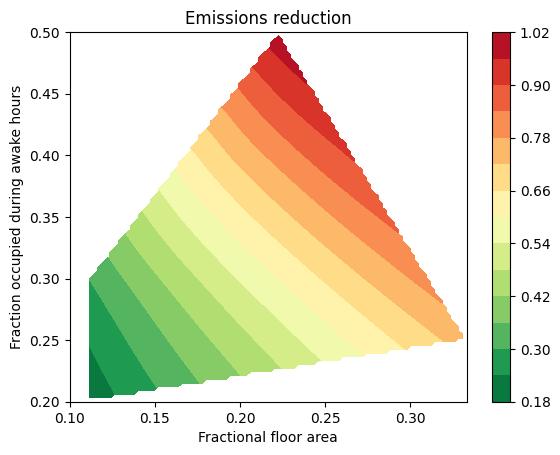

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

points = np.array([(2/9, 0.5), (1/9, 0.2), (2/9, 0.4), (3/9, 0.25), (1/9, 0.3)])
values = np.array([1, 0.2, 0.8, 0.75, 0.3])

grid_x, grid_y = np.mgrid[0.1:0.3333:100j, 0.2:0.5:100j]
grid_z = griddata(points, values, (grid_x, grid_y), method='cubic')

plt.contourf(grid_x, grid_y, grid_z, levels=14, cmap='RdYlGn_r')
plt.colorbar()
#plt.scatter(points[:, 0], points[:, 1], c='black')
plt.title('Emissions reduction')
plt.xlabel('Fractional floor area')
plt.ylabel('Fraction occupied during awake hours')
plt.show()
